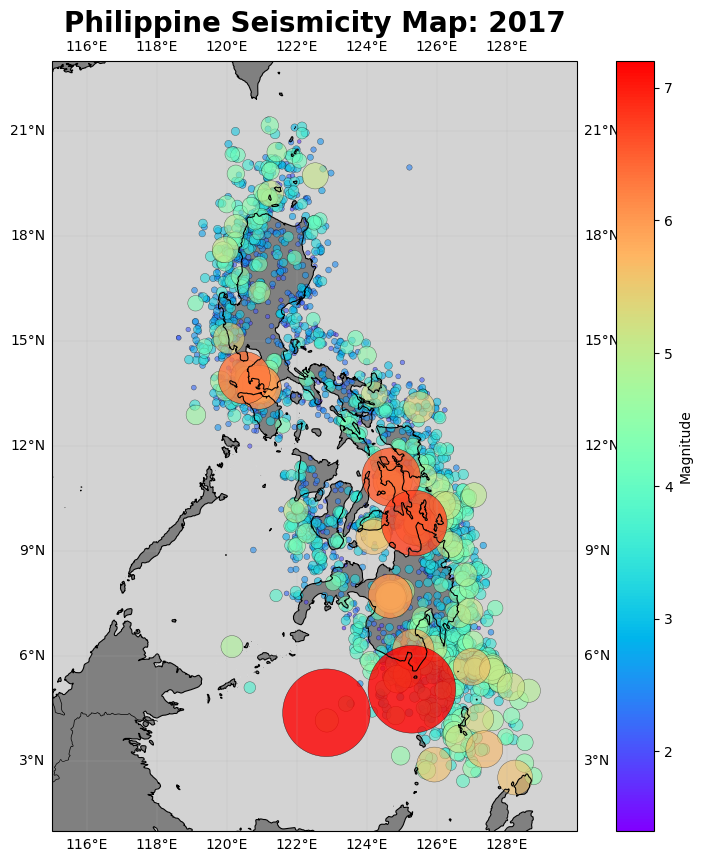

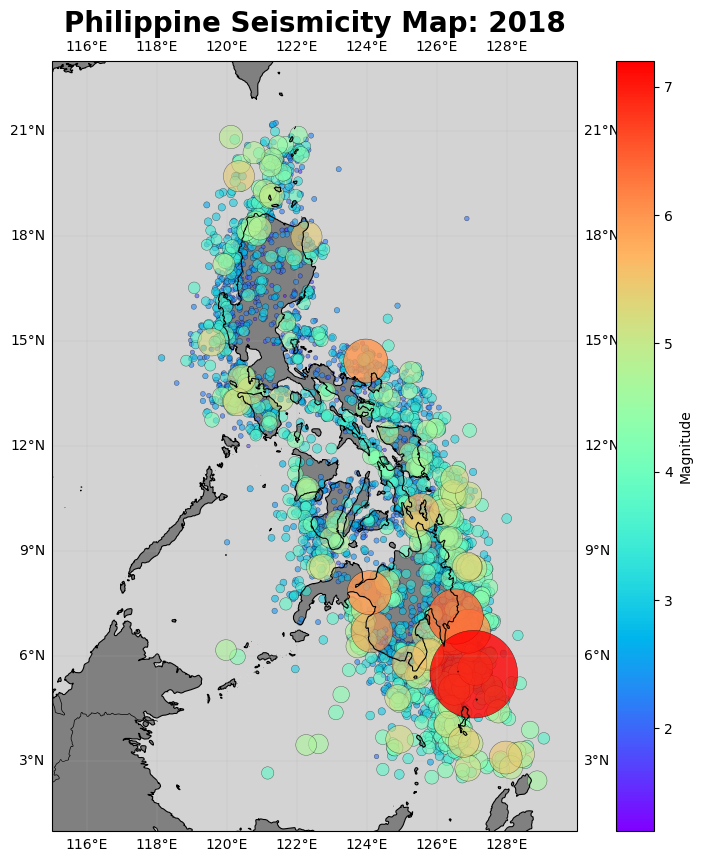

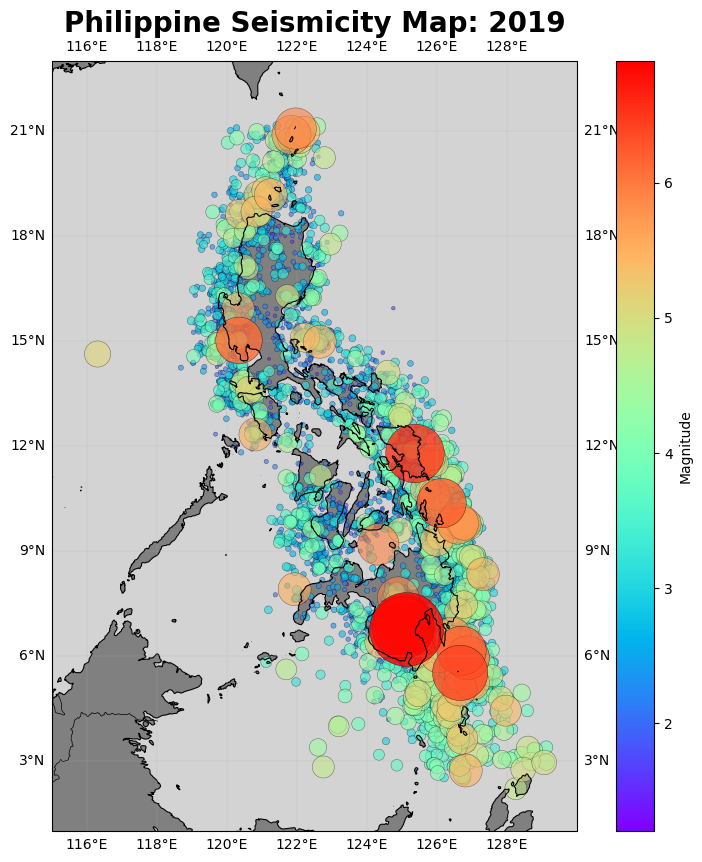

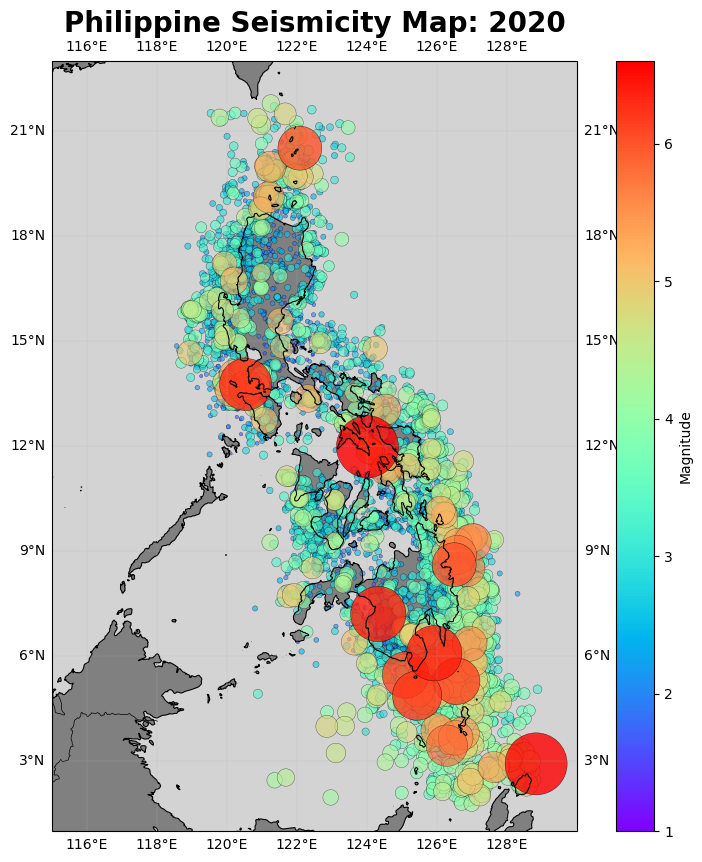

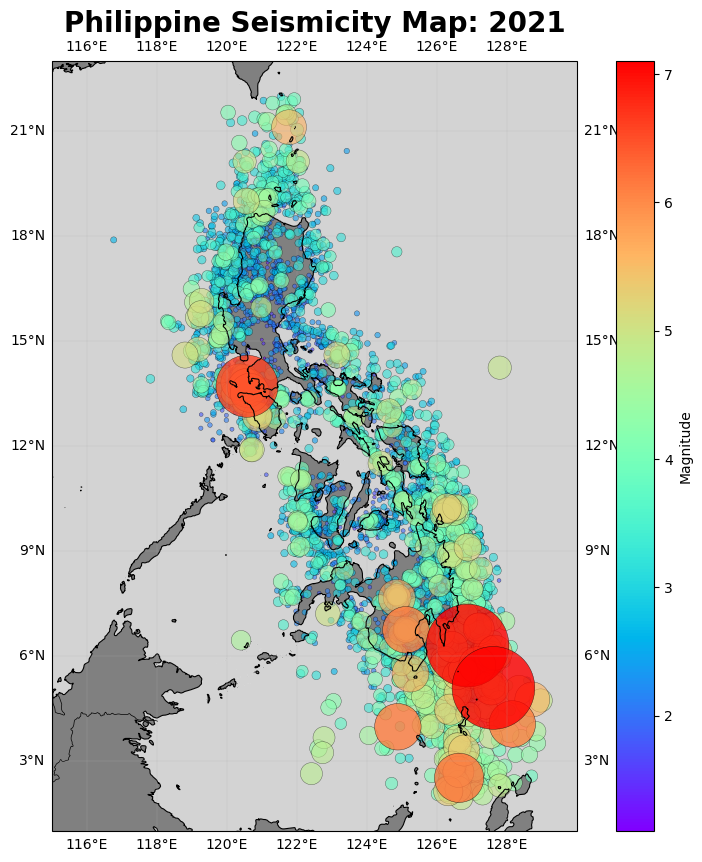

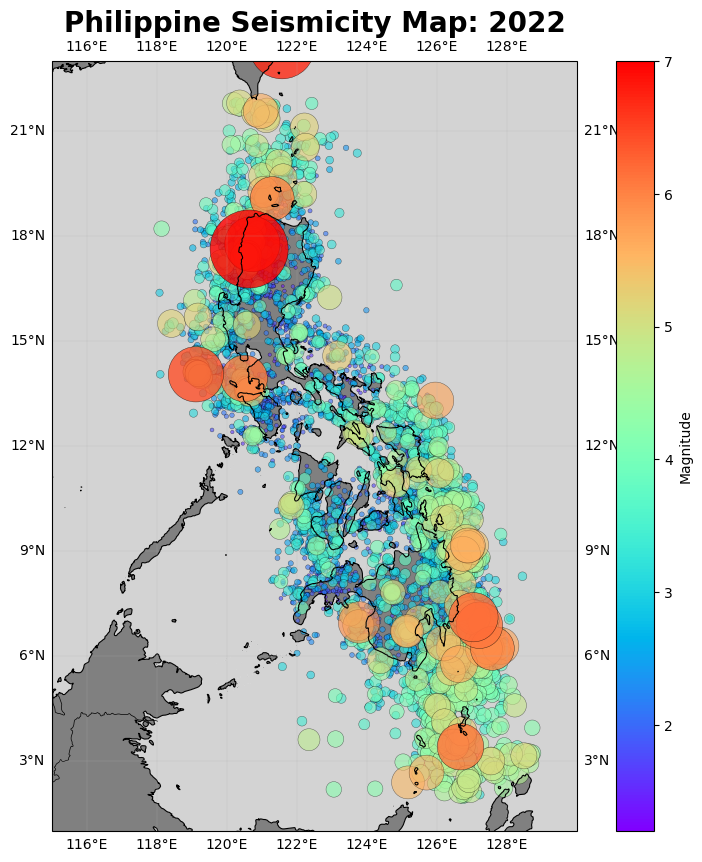

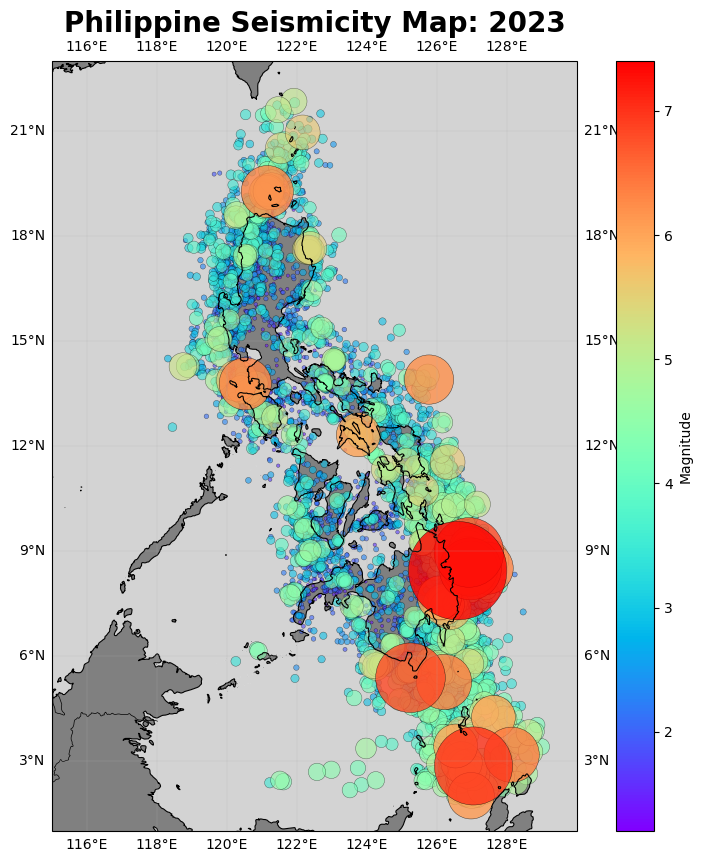

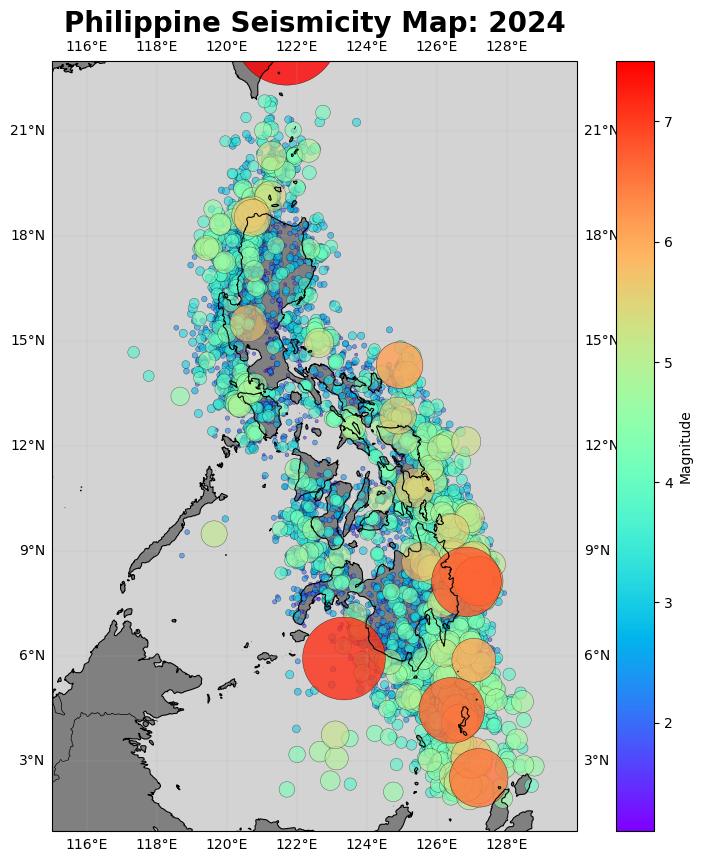

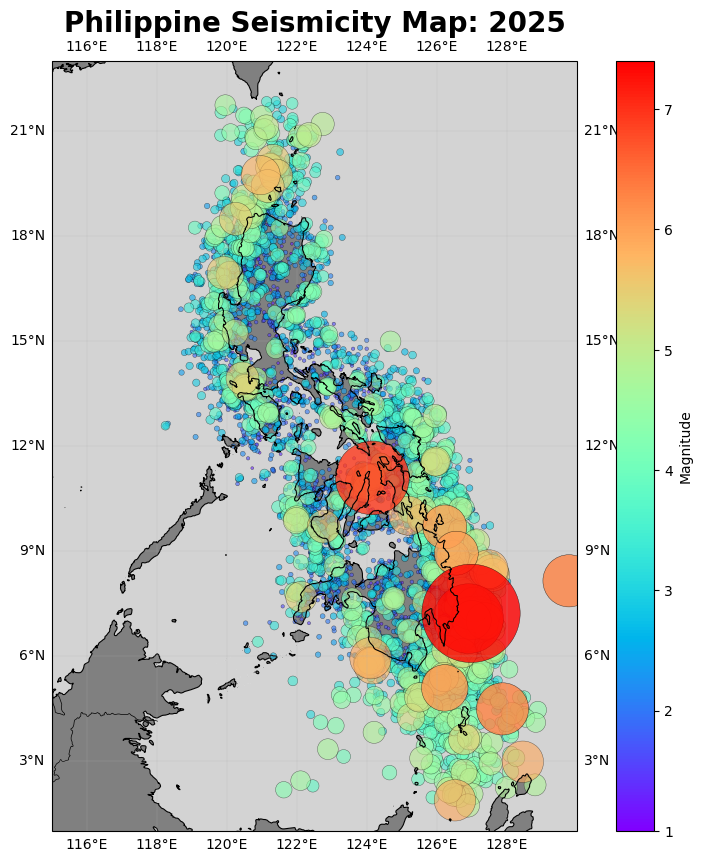

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

EQs = np.array([[5.56,124.78],
                [5.9,126.64],
                [6.8,125.12],
                [11.99,124.04],
                [13.66,120.74],
                [17.5,120.82],
                [8.59,126.39],
                [6.1,123.15],
                [11.12,124.13],
                [7.34,126.69]])

for year in range(2017,2026):

    i=year-2016

    # Load data
    df = pd.read_csv(str(year)+"EQ.csv", sep=",")
    
    # Clean columns
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
    df["mag"] = pd.to_numeric(df["mag"], errors="coerce")
    
    df = df.dropna(subset=["lat", "lon", "mag"])

    df = df.sort_values("mag")

    # Scale magnitude to marker size
    sizes = 10 ** (df["mag"] / 2)
    
    # -------------------------
    # Create map focused on Philippines
    # -------------------------
    fig = plt.figure(figsize=(10, 10))
    
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Geographic extent around the Philippines
    ax.set_extent([115, 130, 1, 23])  # [lon_min, lon_max, lat_min, lat_max]
    
    # Add map features
    ax.add_feature(cfeature.LAND, facecolor="gray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    
    # Optional gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    
    # -------------------------
    # Plot earthquakes
    # -------------------------

    alpha = np.where(df["mag"] < 6, 0.6, 0.8)
    
    sc = ax.scatter(
        df["lon"],
        df["lat"],
        s=sizes,
        c=df["mag"],
        cmap="rainbow",
        alpha=alpha,
        edgecolor="k",
        linewidth=0.3,
        transform=ccrs.PlateCarree()
    )
    
    plt.colorbar(sc, ax=ax, label="Magnitude")
    
    plt.title("Philippine Seismicity Map: "+str(year), weight="bold", size=20)
#comment out for no numbers
    plt.text(EQs[i-1][1], EQs[i-1][0], str(i), ha="center", va="center", fontsize=30, color="white", weight="bold")
#comment out for no numbers
    if (year==2025):
        plt.text(EQs[i][1], EQs[i][0], str(i+1), ha="center", va="center", fontsize=30, color="white", weight="bold")
    plt.savefig("map_"+str(year)+".png")
    plt.show()

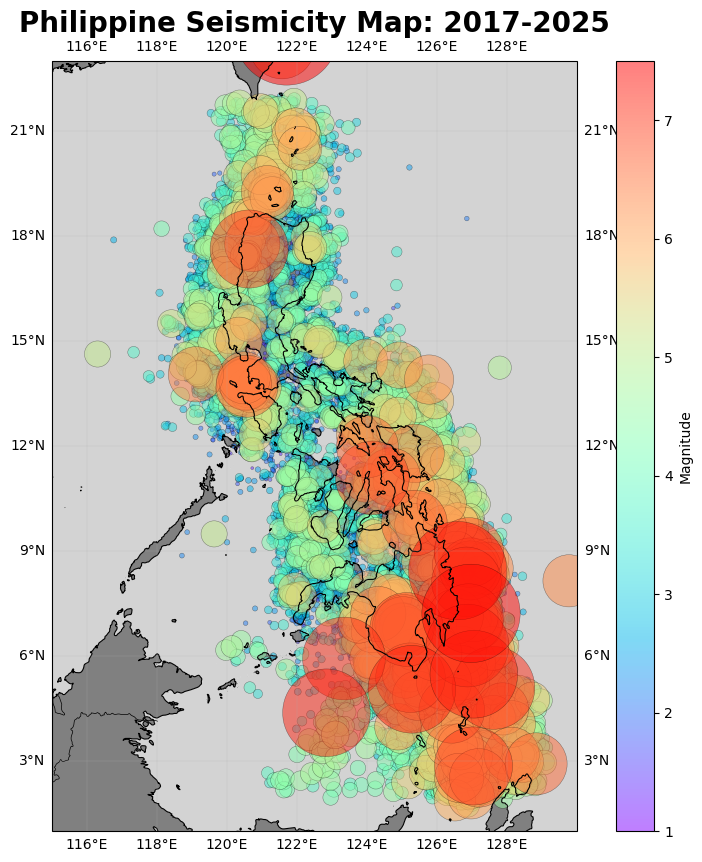

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

EQs = np.array([[5.56,124.78],
                [5.9,126.64],
                [6.8,125.12],
                [11.99,124.04],
                [13.66,120.74],
                [17.5,120.82],
                [8.59,126.39],
                [6.1,123.15],
                [11.12,124.13],
                [7.34,126.69]])

# Load data
df1 = pd.read_csv("2017EQ.csv", sep=",")
df2 = pd.read_csv("2018EQ.csv", sep=",")
df3 = pd.read_csv("2019EQ.csv", sep=",")
df4 = pd.read_csv("2020EQ.csv", sep=",")
df5 = pd.read_csv("2021EQ.csv", sep=",")
df6 = pd.read_csv("2022EQ.csv", sep=",")
df7 = pd.read_csv("2023EQ.csv", sep=",")
df8 = pd.read_csv("2024EQ.csv", sep=",")
df9 = pd.read_csv("2025EQ.csv", sep=",")

df = [df1, df2, df3, df4, df5, df6, df7, df8, df9]
df = pd.concat(df)
    
# Clean columns
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
df["mag"] = pd.to_numeric(df["mag"], errors="coerce")

df = df.dropna(subset=["lat", "lon", "mag"])

df = df.sort_values("mag")

# Scale magnitude to marker size
sizes = 10 ** (df["mag"] / 2)

# -------------------------
# Create map focused on Philippines
# -------------------------
fig = plt.figure(figsize=(10, 10))

ax = plt.axes(projection=ccrs.PlateCarree())

# Geographic extent around the Philippines
ax.set_extent([115, 130, 1, 23])  # [lon_min, lon_max, lat_min, lat_max]

# Add map features
ax.add_feature(cfeature.LAND, facecolor="gray")
ax.add_feature(cfeature.OCEAN, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Optional gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Plot EQs
    
sc = ax.scatter(
    df["lon"],
    df["lat"],
    s=sizes,
    c=df["mag"],
    cmap="rainbow",
    alpha=0.5,
    edgecolor="k",
    linewidth=0.3,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, label="Magnitude")

plt.title("Philippine Seismicity Map: 2017-2025", weight="bold", size=20)

#comment out for no numbers
#for i in range(0,10):
#    plt.text(EQs[i][1], EQs[i][0], str(i+1), ha="center", va="center", fontsize=30, color="white", weight="bold")

plt.savefig("2017-2015.png")
plt.show()